# Aim 1 — Output Logits Extraction + Min/Mean/Max Metrics

Offline HuggingFace run (use a GPU node).

Package: `output_logit_aim1_AND`

For each corpus pair `(word_a, word_b)`:
1. Build typicality prompts `P_A`, `P_B`, `P_AB`
2. Extract Top-K softmax at the final token
3. Compare pointwise **min / mean / max** of `(p_A, p_B)` to `p_AB`

| Module | Role |
|---|---|
| `config.py` | model id, Top-K, paths |
| `prompts.py` | typicality templates |
| `model_io.py` | load model + Top-K extraction |
| `metrics.py` | min / mean / max vs `p_AB` |
| `experiment.py` | corpus loop, resume, save |

In [1]:
import os, socket, torch
print("hostname:", socket.gethostname())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU visible to this kernel")

hostname: gpun203
CUDA_VISIBLE_DEVICES: None
cuda available: True
GPU: NVIDIA A100 80GB PCIe


## 0. Setup (once on the GPU node)

```bash
conda activate ect   # or your GPU env
pip install -r requirements.txt
```

Default model: `Qwen/Qwen3.5-2B` (override with `LOGIT_LENS_MODEL` if needed).

In [2]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import torch

_cwd = Path.cwd().resolve()
_candidates = [
    _cwd,
    _cwd / "output_logit_aim1_AND",
    _cwd / "src" / "output_logit_aim1_AND",
    Path("/home/WUR/lu087/Github/ect/src/output_logit_aim1_AND"),
]
PKG_DIR = next((p for p in _candidates if (p / "experiment.py").exists()), _cwd)
SRC_DIR = PKG_DIR.parent
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import output_logit_aim1_AND.config as _cfg
import output_logit_aim1_AND.prompts as _prompts
import output_logit_aim1_AND.model_io as _mio
import output_logit_aim1_AND.metrics as _metrics
import output_logit_aim1_AND.experiment as _exp
import output_logit_aim1_AND as _pkg

for m in (_cfg, _prompts, _mio, _metrics, _exp, _pkg):
    importlib.reload(m)

from output_logit_aim1_AND import run_experiment
from output_logit_aim1_AND.config import (
    DEFAULT_CORPUS_JSONL,
    DEFAULT_DISTRIBUTIONS_JSONL,
    DEFAULT_METRICS_CSV,
    DEFAULT_OUTPUT_DIR,
    MODEL_ID,
    TOP_K,
)

print("PKG_DIR:", PKG_DIR)
print("MODEL_ID:", MODEL_ID)
print("TOP_K:", TOP_K)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("corpus exists:", DEFAULT_CORPUS_JSONL.exists(), DEFAULT_CORPUS_JSONL)

/home/WUR/lu087/miniconda3/envs/ect/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PKG_DIR: /home/WUR/lu087/Github/ect/src/output_logit_aim1_AND
MODEL_ID: Qwen/Qwen3.5-2B
TOP_K: 4096
cuda available: True
GPU: NVIDIA A100 80GB PCIe
corpus exists: True /home/WUR/lu087/Github/ect/src/vocabulary_gen_aim1_AND/output/orthogonality_spectrum_corpus.jsonl


## 1. Smoke test (a few pairs)

Run this first on the GPU node to verify model download + forward pass.

In [3]:
smoke = run_experiment(
    corpus_path=DEFAULT_CORPUS_JSONL,
    model_id=MODEL_ID,
    top_k=TOP_K,
    max_pairs=2,
    categories=[1],
    resume=False,
    save_every=1,
    distributions_jsonl=DEFAULT_OUTPUT_DIR / "smoke_distributions.jsonl",
    metrics_jsonl=DEFAULT_OUTPUT_DIR / "smoke_metrics.jsonl",
    metrics_csv=DEFAULT_OUTPUT_DIR / "smoke_metrics.csv",
    verbose=True,
)
smoke

model_id=Qwen/Qwen3.5-2B
corpus=/home/WUR/lu087/Github/ect/src/vocabulary_gen_aim1_AND/output/orthogonality_spectrum_corpus.jsonl (n=2, todo=2, done=0)
top_k=4096 device=auto dtype=bfloat16


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 320/320 [00:00<00:00, 761.57it/s]


loaded on cuda, vocab_size=248077
[1/2] cat=1 'Transitive Verb' ∧ 'Verb' | min_cos=0.7921 mean_cos=0.8730 max_cos=0.8717
[2/2] cat=1 'Intransitive Verb' ∧ 'Verb' | min_cos=0.7950 mean_cos=0.8409 max_cos=0.8284
Wrote distributions → /home/WUR/lu087/Github/ect/src/output_logit_aim1_AND/output/smoke_distributions.jsonl
Wrote metrics JSONL → /home/WUR/lu087/Github/ect/src/output_logit_aim1_AND/output/smoke_metrics.jsonl
Wrote metrics CSV   → /home/WUR/lu087/Github/ect/src/output_logit_aim1_AND/output/smoke_metrics.csv


{'n_total': 2,
 'n_done_before': 0,
 'n_new': 2,
 'distributions_jsonl': '/home/WUR/lu087/Github/ect/src/output_logit_aim1_AND/output/smoke_distributions.jsonl',
 'metrics_csv': '/home/WUR/lu087/Github/ect/src/output_logit_aim1_AND/output/smoke_metrics.csv'}

## 2. Full experiment

Writes:
- `output/extracted_distributions_top4096.jsonl` — Top-K token ids + probs for `P_A`, `P_B`, `P_AB`
- `output/composition_metrics_min_mean_max.jsonl` / `.csv` — min/mean/max vs `p_AB`

`resume=True` skips pairs already in the metrics file.

In [4]:
# Tunables
CATEGORIES = None          # e.g. [1, 2, 3, 4, 5] or None for all
MAX_PAIRS = None           # set an int to cap; None = full corpus

result = run_experiment(
    corpus_path=DEFAULT_CORPUS_JSONL,
    model_id=MODEL_ID,
    top_k=TOP_K,
    device="auto",         # uses CUDA if available
    dtype_name="bfloat16", # good default on modern GPUs
    max_pairs=MAX_PAIRS,
    categories=CATEGORIES,
    resume=True,
    save_every=25,
    verbose=True,
)
result

model_id=Qwen/Qwen3.5-2B
corpus=/home/WUR/lu087/Github/ect/src/vocabulary_gen_aim1_AND/output/orthogonality_spectrum_corpus.jsonl (n=3885, todo=3885, done=0)
top_k=4096 device=auto dtype=bfloat16


Loading weights: 100%|██████████| 320/320 [00:00<00:00, 5751.41it/s]


loaded on cuda, vocab_size=248077
[1/3885] cat=1 'Transitive Verb' ∧ 'Verb' | min_cos=0.7921 mean_cos=0.8730 max_cos=0.8717
[10/3885] cat=1 'Superlative Adjective' ∧ 'Adjective' | min_cos=0.7730 mean_cos=0.8813 max_cos=0.8951
[20/3885] cat=1 'Definite Article' ∧ 'Determiner' | min_cos=0.9626 mean_cos=0.8275 max_cos=0.7599
[30/3885] cat=1 'Relative Clause' ∧ 'Clause' | min_cos=0.8956 mean_cos=0.9316 max_cos=0.9371
[40/3885] cat=1 'Exclamatory Sentence' ∧ 'Sentence' | min_cos=0.9294 mean_cos=0.9505 max_cos=0.9457
[50/3885] cat=1 'Active Voice' ∧ 'Voice' | min_cos=0.6829 mean_cos=0.7169 max_cos=0.7019
[60/3885] cat=1 'Sleet' ∧ 'Precipitation' | min_cos=0.8026 mean_cos=0.9016 max_cos=0.9382
[70/3885] cat=1 'Cold Front' ∧ 'Front' | min_cos=0.8110 mean_cos=0.9066 max_cos=0.9007
[80/3885] cat=1 'Haze' ∧ 'Visibility Condition' | min_cos=0.9451 mean_cos=0.9477 max_cos=0.9363
[90/3885] cat=1 'Macroburst' ∧ 'Downburst' | min_cos=0.9606 mean_cos=0.9595 max_cos=0.9457
[100/3885] cat=1 'Sun Dog' ∧ '

{'n_total': 3885,
 'n_done_before': 0,
 'n_new': 3885,
 'distributions_jsonl': '/home/WUR/lu087/Github/ect/src/output_logit_aim1_AND/output/extracted_distributions_top4096.jsonl',
 'metrics_csv': '/home/WUR/lu087/Github/ect/src/output_logit_aim1_AND/output/composition_metrics_min_mean_max.csv'}

## 3. Quick look at metrics

In [5]:
import pandas as pd

df = pd.read_csv(DEFAULT_METRICS_CSV)
cols = [
    "category_id",
    "word_a",
    "word_b",
    "min_cosine_to_ab",
    "mean_cosine_to_ab",
    "max_cosine_to_ab",
    "min_mass",
    "mean_mass",
    "max_mass",
]
display(df[cols].head(10))
display(df.groupby("category_id")[["min_cosine_to_ab", "mean_cosine_to_ab", "max_cosine_to_ab"]].mean())

,category_id,word_a,word_b,min_cosine_to_ab,mean_cosine_to_ab,max_cosine_to_ab,min_mass,mean_mass,max_mass
0,1,Transitive Verb,Verb,0.792052,0.872985,0.871668,0.172383,0.922897,1.673410
1,1,Intransitive Verb,Verb,0.795018,0.840907,0.828431,0.161184,0.924188,1.687191
2,1,Auxiliary Verb,Verb,0.807138,0.916900,0.924603,0.201404,0.918734,1.636065
3,1,Irregular Noun,Noun,0.253813,0.272009,0.286046,0.706525,0.963513,1.220501
4,1,Countable Noun,Noun,0.195157,0.210014,0.220451,0.707240,0.964580,1.221920
5,1,Mass Noun,Noun,0.901101,0.901904,0.894400,0.660283,0.959894,1.259504
6,1,Proper Noun,Noun,0.968726,0.968642,0.955460,0.670834,0.969862,1.268890
7,1,Common Noun,Noun,0.463646,0.477475,0.486450,0.731036,0.965690,1.200344
8,1,Comparative Adjective,Adjective,0.773535,0.880760,0.910801,0.417969,0.966942,1.515915
9,1,Superlative Adjective,Adjective,0.772960,0.881331,0.895090,0.391408,0.969935,1.548462


,min_cosine_to_ab,mean_cosine_to_ab,max_cosine_to_ab
category_id,,,
1,0.842812,0.896895,0.889710
2,0.807813,0.798453,0.776728
3,0.808295,0.826194,0.814661
4,0.815063,0.846145,0.836147
5,0.804227,0.833336,0.831866


## 4. Rank-aligned difference curves (min / mean / max vs p_AB)

For each pair:
1. Sort ground-truth `p_AB` Top-4096 tokens by probability (high → low)
2. At those tokens, evaluate pointwise **min / mean / max** of `(p_A, p_B)` (missing Top-K mass = 0)
3. Record absolute difference `|agg − p_AB|` at each rank

Per category, plot the **mean** curve and the **5% / 95%** quantile ribbon across pairs.
X = token rank (0 = highest `p_AB` probability).

In [8]:
import importlib

import output_logit_aim1_AND.rank_diff as _rank_diff

importlib.reload(_rank_diff)
from output_logit_aim1_AND.rank_diff import (
    compute_rank_diff_summary,
    load_rank_diff_summary,
    plot_category_rank_diffs,
    save_rank_diff_summary,
)

RANK_DIFF_NPZ = DEFAULT_OUTPUT_DIR / "rank_diff_summary_q05_q95.npz"
RANK_DIFF_FIG_DIR = DEFAULT_OUTPUT_DIR / "figures_rank_diff"

# Set True to recompute from the 1.4GB distributions JSONL (~a few minutes).
RECOMPUTE_RANK_DIFFS = not RANK_DIFF_NPZ.exists()

if RECOMPUTE_RANK_DIFFS:
    print("Computing rank-aligned diffs from", DEFAULT_DISTRIBUTIONS_JSONL)
    rank_summary = compute_rank_diff_summary(DEFAULT_DISTRIBUTIONS_JSONL, q_low=0.05, q_high=0.95)
    save_rank_diff_summary(rank_summary, RANK_DIFF_NPZ)
    print("Wrote", RANK_DIFF_NPZ)
else:
    print("Loading cached summary", RANK_DIFF_NPZ)
    rank_summary = load_rank_diff_summary(RANK_DIFF_NPZ)

for cid, blob in sorted(rank_summary.items()):
    print(f"cat={cid} n={blob['n_pairs']} K={blob['top_k']} | {blob['category_name']}")

Loading cached summary /home/WUR/lu087/Github/ect/src/output_logit_aim1_AND/output/rank_diff_summary_q05_q95.npz
cat=1 n=799 K=4096 | Redundant / Strict Entailment
cat=2 n=795 K=4096 | Typical Composition
cat=3 n=750 K=4096 | Uncommon / Orthogonal
cat=4 n=795 K=4096 | Surreal / Out-of-Distribution
cat=5 n=746 K=4096 | Mutually Exclusive / Paradoxical


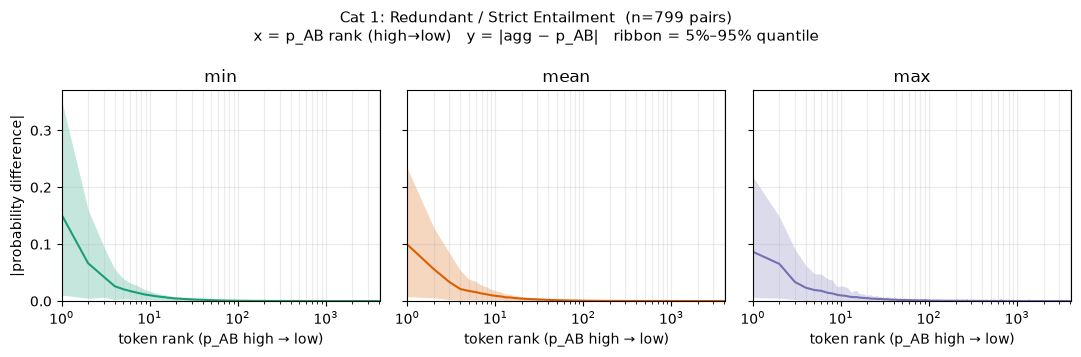

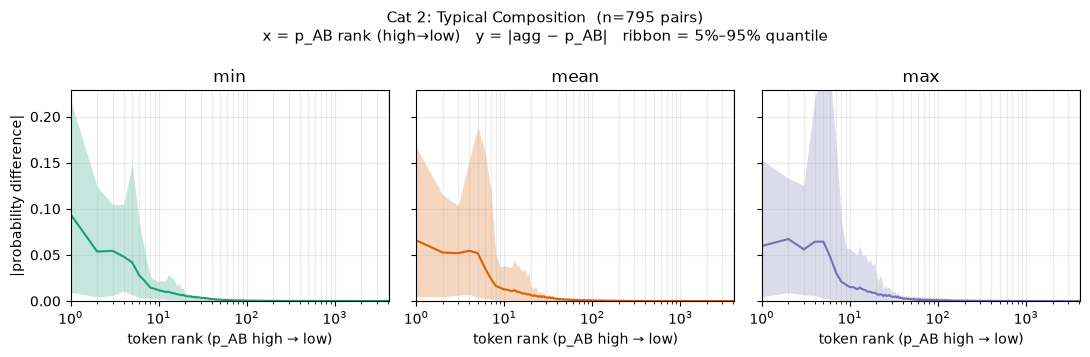

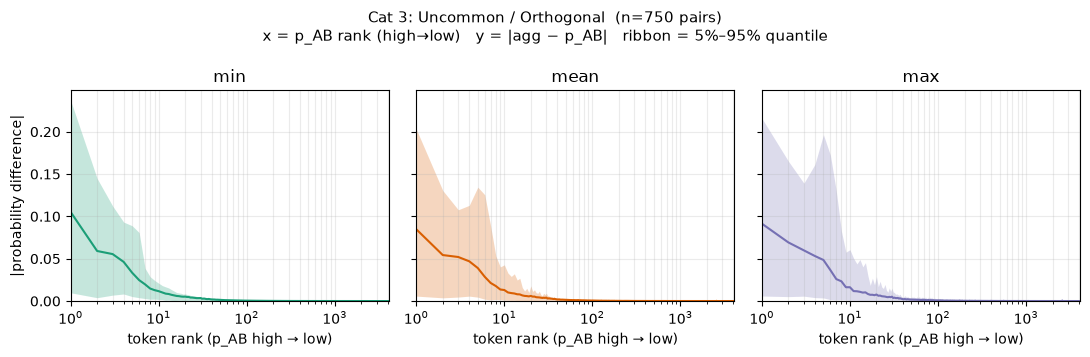

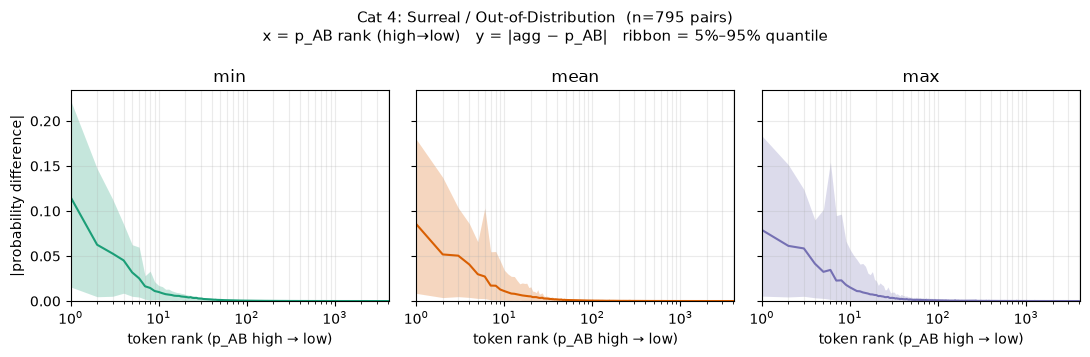

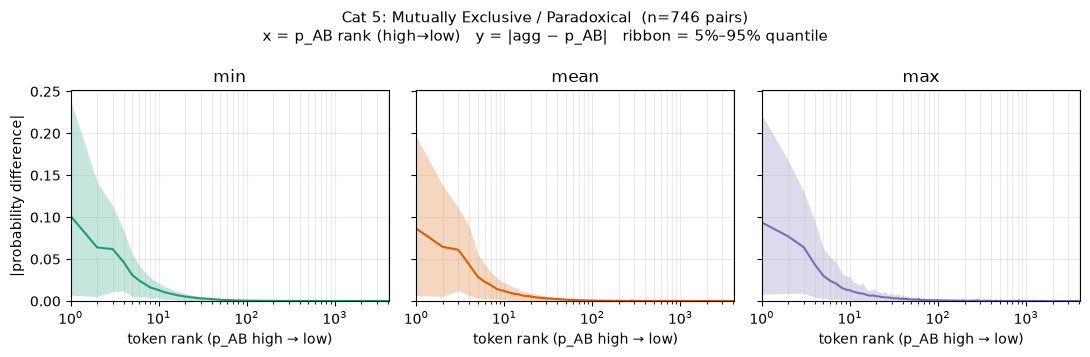

Saved figures:
  /home/WUR/lu087/Github/ect/src/output_logit_aim1_AND/output/figures_rank_diff/rank_diff_cat1.png
  /home/WUR/lu087/Github/ect/src/output_logit_aim1_AND/output/figures_rank_diff/rank_diff_cat2.png
  /home/WUR/lu087/Github/ect/src/output_logit_aim1_AND/output/figures_rank_diff/rank_diff_cat3.png
  /home/WUR/lu087/Github/ect/src/output_logit_aim1_AND/output/figures_rank_diff/rank_diff_cat4.png
  /home/WUR/lu087/Github/ect/src/output_logit_aim1_AND/output/figures_rank_diff/rank_diff_cat5.png


In [9]:
paths = plot_category_rank_diffs(
    rank_summary,
    out_dir=RANK_DIFF_FIG_DIR,
    show=True,
    log_x=True,  # expand the probability head; set False for linear 0..4095
)
print("Saved figures:")
for p in paths:
    print(" ", p)